# HAL-TMLE for the Right-Censored Density L2 Target

This notebook demos the package API for

```text
Psi(P) = integral p(t)^2 dt
```

under right censoring. It mirrors the right-censored mean demo: one representative seed, then a compact parallel Monte Carlo sweep. Stage 1 is always CV-tuned and then refit with the selected norm constraint and basis order.

The fluctuation direction follows the supplied estimating direction, up to an irrelevant additive constant that is removed by centering before exponential tilting:

```text
H(t) = 2 p(t) / Gbar(t) - integral_0^t 2 E[p(T) | T > u] dG_C(u) / Gbar(u)^2.
```


In [1]:
from __future__ import annotations

from contextlib import contextmanager
from pathlib import Path
import os
import sys
import time
from typing import Any

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from joblib import Parallel, delayed
from tqdm import tqdm

ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "pyproject.toml").exists() and (p / "src").exists()
)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from haldensity.censoring.right.estimators import RightCensoredInitEstimator
from haldensity.censoring.right.km import KaplanMeier
from haldensity.censoring.right.weights import compute_ipcw_weights
from haldensity.censoring.tuners.right_tuners import RightCensoredInitTuner
from haldensity.targeting import right_censored_density_l2_targeting_M_step
from haldensity.utils import TruncatedGMM

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

REPRESENTATIVE_SEED = 7
N = 800

REFERENCE_GMM = {
    "components": [
        {"mean": 0.25, "std": 0.07, "lower": 0.0, "upper": 1.0},
        {"mean": 0.65, "std": 0.10, "lower": 0.0, "upper": 1.0},
    ],
    "weights": [0.45, 0.55],
}
CENSOR_LOW = 0.0
CENSOR_HIGH = 1.0

GBAR_CLIP = 1e-6
SURVIVAL_CLIP = 1e-8
TMLE_MODE = "iterative"
TMLE_MAX_ITER = 10
ONE_STEP_EIF_GATE = 1e-8

# Cheat/oracle mode for this simulation DGP: C ~ Uniform(0, 1).
# The oracle object supplies Gbar(t)=P(C>t)=1-t and a fine pseudo-jump grid
# so the TMLE direction can approximate the continuous dG_C integral.
USE_ORACLE_UNIFORM_CENSORING = False
ORACLE_CENSORING_GRID_SIZE = 2000

CV_FOLDS = 5
N_TRIALS = 25
N_GRID_POINTS = 100
STAGE1_SOLVER = "ECOS"
STAGE1_TUNING_OVERRIDES = {
    "basis_order": [1],
    "norm_constraint": {"low": 1.0, "high": 1000.0, "log": True},
}

SMALL_MC_N_SEEDS = 100
SMALL_MC_SEEDS = list(range(1, SMALL_MC_N_SEEDS + 1))
SMALL_MC_N_WORKERS = 10
GBAR_DIAGNOSTIC_MIN = 0.02

run_config = pd.DataFrame([
    {
        "representative_seed": REPRESENTATIVE_SEED,
        "n": N,
        "target": "integral p(t)^2 dt",
        "cv_folds": CV_FOLDS,
        "n_trials": N_TRIALS,
        "n_grid_points": N_GRID_POINTS,
        "tmle_mode": TMLE_MODE,
        "tmle_max_iter": TMLE_MAX_ITER,
        "use_oracle_uniform_censoring": USE_ORACLE_UNIFORM_CENSORING,
        "oracle_censoring_grid_size": ORACLE_CENSORING_GRID_SIZE if USE_ORACLE_UNIFORM_CENSORING else np.nan,
        "small_mc_n_seeds": SMALL_MC_N_SEEDS,
        "small_mc_n_workers": SMALL_MC_N_WORKERS,
        "gbar_diagnostic_min": GBAR_DIAGNOSTIC_MIN,
        "root": str(ROOT),
    }
])
display(run_config)


/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,representative_seed,n,target,cv_folds,n_trials,n_grid_points,tmle_mode,tmle_max_iter,use_oracle_uniform_censoring,oracle_censoring_grid_size,small_mc_n_seeds,small_mc_n_workers,gbar_diagnostic_min,root
0,7,800,integral p(t)^2 dt,5,25,100,iterative,10,False,NaN,100,10,0.02,/Users/houyilong/GitHub/HALDensity


## Helpers

The true target is computed by numerical integration of the known DGP density. The Stage 1 fit reuses one censoring KM object for IPCW weights and TMLE, matching the right-censored survival and mean demos.


In [2]:
def make_sampler() -> TruncatedGMM:
    return TruncatedGMM(**REFERENCE_GMM)


def true_density_l2_from_sampler(sampler: TruncatedGMM, *, n_grid: int = 20_001) -> float:
    grid = np.linspace(0.0, 1.0, n_grid)
    density = sampler.compute_density(grid)
    return float(np.trapz(np.square(density), grid))


def simulate_reference_right_censored_dgp(n: int, *, seed: int) -> dict[str, Any]:
    np.random.seed(seed)
    sampler = make_sampler()
    event_time = sampler.generate_samples(n)
    censor_time = np.random.uniform(CENSOR_LOW, CENSOR_HIGH, size=n)
    observed_time = np.minimum(event_time, censor_time)
    delta = (event_time <= censor_time).astype(int)
    data = pd.DataFrame({"T": observed_time, "Delta": delta})
    return {
        "observed_data": data,
        "truth": {
            "density_l2": true_density_l2_from_sampler(sampler),
            "density_fn": lambda t, _sampler=sampler: _sampler.compute_density(np.asarray(t, dtype=float)),
        },
    }


class UniformCensoringOracle:
    """Known censoring law for the simulation cheat mode: C ~ Uniform(low, high)."""

    def __init__(self, *, low: float, high: float, n_grid: int):
        if not high > low:
            raise ValueError("high must be greater than low")
        if n_grid < 2:
            raise ValueError("n_grid must be at least 2")
        self.low = float(low)
        self.high = float(high)
        self.n_grid = int(n_grid)

    def predict(self, t: np.ndarray | float) -> np.ndarray:
        values = np.asarray(t, dtype=float)
        survival = (self.high - values) / (self.high - self.low)
        survival = np.where(values < self.low, 1.0, survival)
        survival = np.where(values >= self.high, 0.0, survival)
        return np.clip(survival, 0.0, 1.0)

    def stepwise_survival_(self) -> tuple[np.ndarray, np.ndarray]:
        # Approximate the continuous uniform dG_C integral without adding an
        # artificial endpoint jump where Gbar(1)=0.
        jump_times = np.linspace(self.low, self.high, self.n_grid + 1, dtype=float)[1:-1]
        return jump_times, self.predict(jump_times)


def make_censoring_model(data: pd.DataFrame, *, use_oracle_uniform_censoring: bool = USE_ORACLE_UNIFORM_CENSORING):
    if use_oracle_uniform_censoring:
        return UniformCensoringOracle(
            low=CENSOR_LOW,
            high=CENSOR_HIGH,
            n_grid=ORACLE_CENSORING_GRID_SIZE,
        )
    return KaplanMeier().fit(data, time_col="T", delta_col="Delta")


def fit_stage1_ipcw(
    data: pd.DataFrame,
    *,
    seed: int,
    use_oracle_uniform_censoring: bool = USE_ORACLE_UNIFORM_CENSORING,
) -> dict[str, Any]:
    tic = time.perf_counter()
    estimated_km = KaplanMeier().fit(data, time_col="T", delta_col="Delta")
    censoring_model = make_censoring_model(
        data,
        use_oracle_uniform_censoring=use_oracle_uniform_censoring,
    )
    t_vals = data["T"].to_numpy(dtype=float)
    delta_vals = data["Delta"].to_numpy(dtype=int)
    weights = compute_ipcw_weights(
        T=t_vals,
        Delta=delta_vals,
        S_c_predict=lambda t: np.atleast_1d(estimated_km.predict(t)),
        clip=GBAR_CLIP,
    )
    uncensored_mask = delta_vals == 1
    if not np.any(uncensored_mask):
        raise RuntimeError("No uncensored event times are available for the IPCW-HAL initializer.")

    tuner = RightCensoredInitTuner(
        data=data,
        cv_folds=CV_FOLDS,
        random_state=seed,
        n_grid_points=N_GRID_POINTS,
        param_overrides=STAGE1_TUNING_OVERRIDES,
        use_conservative_adjustment=False,
        validation_metric="observed_loglik",
        clip=GBAR_CLIP,
        silent=True,
    )
    tuning_result = tuner.optimize(n_trials=N_TRIALS)
    norm_constraint = float(tuning_result.best_params["norm_constraint"])
    basis_order = int(tuning_result.best_params["basis_order"])
    best_params = dict(tuning_result.best_params)

    uncensored_df = pd.DataFrame({"W1": t_vals[uncensored_mask]})
    estimator = RightCensoredInitEstimator(
        tol=1e-8,
        norm_constraint=norm_constraint,
        n_grid_points=N_GRID_POINTS,
        basis_order=basis_order,
        solver=STAGE1_SOLVER,
        use_secondary_solver=True,
    )
    estimator.fit(uncensored_df, sample_weights=weights[uncensored_mask])

    gbar_vals = np.asarray(estimated_km.predict(t_vals), dtype=float)
    return {
        "estimator": estimator,
        "km": estimated_km,
        "estimated_km": estimated_km,
        "weights": weights,
        "best_params": best_params,
        "runtime_seconds": float(time.perf_counter() - tic),
        "diagnostics": {
            "n_uncensored": int(uncensored_mask.sum()),
            "censoring_rate": float(1.0 - delta_vals.mean()),
            "censoring_model": "km_estimated",
            "oracle_censoring_grid_size": np.nan,
            "min_positive_ipcw_weight": float(np.min(weights[weights > 0])) if np.any(weights > 0) else float("nan"),
            "max_ipcw_weight": float(np.max(weights)) if weights.size else float("nan"),
            "min_gbar": float(np.min(gbar_vals)) if gbar_vals.size else float("nan"),
            "min_gbar_clipped": float(np.min(np.maximum(gbar_vals, GBAR_CLIP))) if gbar_vals.size else float("nan"),
        },
    }


def run_density_l2_tmle(
    stage1_fit: dict[str, Any],
    data: pd.DataFrame,
    *,
    store_pointwise_arrays: bool,
    use_oracle_uniform_censoring: bool = USE_ORACLE_UNIFORM_CENSORING,
) -> dict[str, Any]:
    tmle_censoring_model = make_censoring_model(
        data,
        use_oracle_uniform_censoring=use_oracle_uniform_censoring,
    )
    return right_censored_density_l2_targeting_M_step(
        initial_estimator=stage1_fit["estimator"],
        observed_data=data,
        km=tmle_censoring_model,
        mode=TMLE_MODE,
        one_step_eif_gate=ONE_STEP_EIF_GATE,
        clip=GBAR_CLIP,
        survival_clip=SURVIVAL_CLIP,
        max_iter=TMLE_MAX_ITER,
        store_pointwise_arrays=store_pointwise_arrays,
    )


## Representative Seed

Fit the CV-IPCW initial density once, then compare the plug-in estimate with TMLE using estimated KM censoring and TMLE using oracle `Uniform(0, 1)` censoring. The score table reports `PnD*` before and after targeting for each TMLE score. For inference, the density-L2 TMLE now treats the regularized estimator as primary: `standard_error` and the Wald CI use all regularized EICs, while the clip-active filtered SE is retained only as a diagnostic.


n=800, uncensored=397, censored=403
censoring rate: 50.4%
true density L2 target: 1.6776


/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_93973/2945942801.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(np.square(density), grid))


,T,Delta
0,0.046626,0
1,0.144617,1
2,0.438131,0
3,0.079117,1
4,0.211161,1


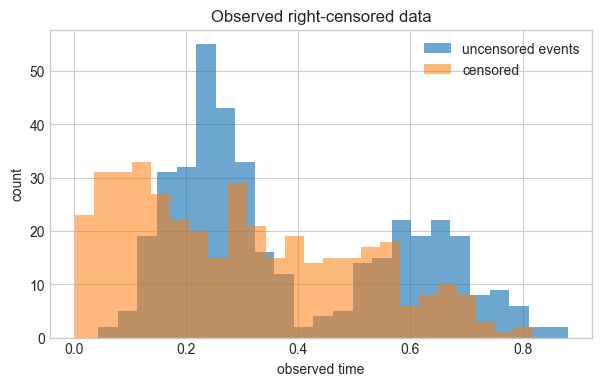

In [3]:
simulation = simulate_reference_right_censored_dgp(n=N, seed=REPRESENTATIVE_SEED)
observed_data = simulation["observed_data"]
truth = simulation["truth"]

print(f"n={len(observed_data)}, uncensored={int(observed_data['Delta'].sum())}, censored={int((1 - observed_data['Delta']).sum())}")
print(f"censoring rate: {1.0 - observed_data['Delta'].mean():.1%}")
print(f"true density L2 target: {truth['density_l2']:.4f}")
display(observed_data.head())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(observed_data.loc[observed_data["Delta"] == 1, "T"], bins=24, alpha=0.65, label="uncensored events")
ax.hist(observed_data.loc[observed_data["Delta"] == 0, "T"], bins=24, alpha=0.55, label="censored")
ax.set_xlabel("observed time")
ax.set_ylabel("count")
ax.set_title("Observed right-censored data")
ax.legend()
plt.show()


In [4]:
stage1_fit = fit_stage1_ipcw(observed_data, seed=REPRESENTATIVE_SEED)
targeted_km = run_density_l2_tmle(
    stage1_fit,
    observed_data,
    store_pointwise_arrays=True,
    use_oracle_uniform_censoring=False,
)
targeted_oracle = run_density_l2_tmle(
    stage1_fit,
    observed_data,
    store_pointwise_arrays=True,
    use_oracle_uniform_censoring=True,
)
summary_km = targeted_km["summary"].iloc[0]
summary_oracle = targeted_oracle["summary"].iloc[0]
summary = targeted_km["summary"].copy()
pointwise_fit_km = targeted_km["pointwise_fits"][0]
pointwise_fit_oracle = targeted_oracle["pointwise_fits"][0]
pointwise_fit = pointwise_fit_km

comparison = pd.DataFrame([
    {"method": "truth", "estimate": truth["density_l2"], "error": 0.0, "score_model": None, "pnd_star": np.nan},
    {"method": "CV-IPCW plug-in", "estimate": float(summary_km["density_l2_init"]), "error": float(summary_km["density_l2_init"] - truth["density_l2"]), "score_model": "KM", "pnd_star": float(summary_km["eif_mean_initial_stage"])},
    {"method": "TMLE density L2", "estimate": float(summary_km["density_l2_star"]), "error": float(summary_km["density_l2_star"] - truth["density_l2"]), "score_model": "KM", "pnd_star": float(summary_km["eif_mean_final"])},
    {"method": "TMLE density L2 (oracle Gbar)", "estimate": float(summary_oracle["density_l2_star"]), "error": float(summary_oracle["density_l2_star"] - truth["density_l2"]), "score_model": "oracle Uniform(0,1)", "pnd_star": float(summary_oracle["eif_mean_final"])},
])

score_diagnostics = pd.DataFrame([
    {"method": "CV-IPCW plug-in", "score_model": "KM", "pnd_star": float(summary_km["eif_mean_initial_stage"]), "abs_pnd_star": abs(float(summary_km["eif_mean_initial_stage"]))},
    {"method": "TMLE density L2", "score_model": "KM", "pnd_star": float(summary_km["eif_mean_final"]), "abs_pnd_star": abs(float(summary_km["eif_mean_final"]))},
    {"method": "TMLE density L2 (oracle Gbar)", "score_model": "oracle Uniform(0,1)", "pnd_star": float(summary_oracle["eif_mean_final"]), "abs_pnd_star": abs(float(summary_oracle["eif_mean_final"]))},
])

summary_display = (
    pd.concat([
        summary_km.to_frame().T.assign(censoring_model="KM"),
        summary_oracle.to_frame().T.assign(censoring_model="oracle_uniform"),
    ], ignore_index=True)[[
        "censoring_model",
        "targeting_gbar_floor",
        "density_l2_init",
        "density_l2_star",
        "standard_error",
        "standard_error_clip_active_filtered",
        "clip_active_eic_excluded_count",
        "clip_active_eic_excluded_rate",
        "ci_lower",
        "ci_upper",
        "eif_mean_initial_stage",
        "eif_mean_final",
        "epsilon_last",
        "n_iterations",
        "stop_reason",
        "converged",
    ]]
    .rename(columns={
        "standard_error": "standard_error_default",
        "standard_error_clip_active_filtered": "standard_error_clip_active_filtered_diag",
    })
)

display(pd.DataFrame([stage1_fit["diagnostics"] | stage1_fit["best_params"]]))
display(comparison)
display(score_diagnostics)
display(summary_display)


,n_uncensored,censoring_rate,censoring_model,oracle_censoring_grid_size,min_positive_ipcw_weight,max_ipcw_weight,min_gbar,min_gbar_clipped,basis_order,norm_constraint
0,397,0.50375,km_estimated,NaN,1.038961,8.96188,0.111584,0.111584,1,172.98081


,method,estimate,error,score_model,pnd_star
0,truth,1.677622,0.000000,None,NaN
1,CV-IPCW plug-in,1.652395,-0.025227,KM,0.020771
2,TMLE density L2,1.672799,-0.004823,KM,-0.000073
3,TMLE density L2 (oracle Gbar),1.673115,-0.004507,"oracle Uniform(0,1)",-0.000093


,method,score_model,pnd_star,abs_pnd_star
0,CV-IPCW plug-in,KM,0.020771,0.020771
1,TMLE density L2,KM,-0.000073,0.000073
2,TMLE density L2 (oracle Gbar),"oracle Uniform(0,1)",-0.000093,0.000093


,censoring_model,targeting_gbar_floor,density_l2_init,density_l2_star,standard_error_default,standard_error_clip_active_filtered_diag,clip_active_eic_excluded_count,clip_active_eic_excluded_rate,ci_lower,ci_upper,eif_mean_initial_stage,eif_mean_final,epsilon_last,n_iterations,stop_reason,converged
0,KM,0.026445,1.652395,1.672799,0.070563,0.070563,0,0.0,1.534496,1.811102,0.020771,-0.000073,0.005162,1,score_tolerance,True
1,oracle_uniform,0.026445,1.652395,1.673115,0.063523,0.119467,403,0.50375,1.54861,1.797621,0.019041,-0.000093,0.00581,1,score_tolerance,True


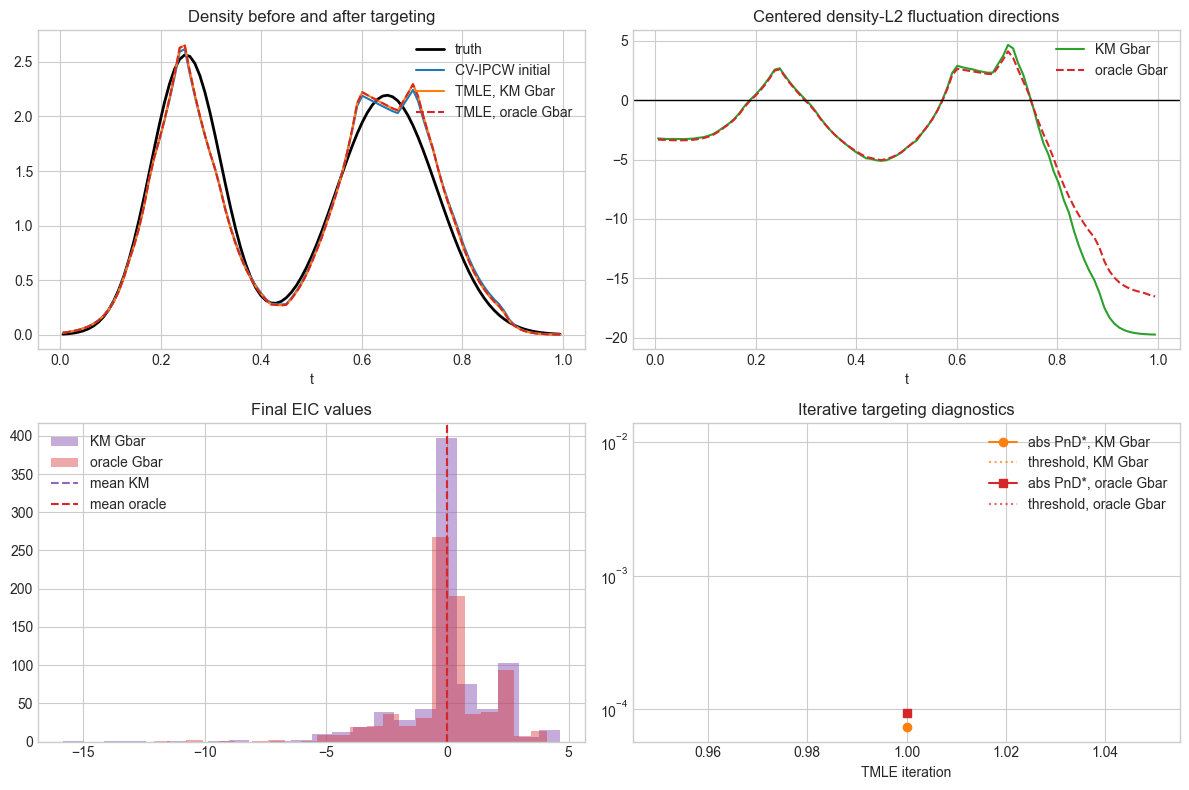

In [5]:
grid = np.asarray(pointwise_fit_km["grid_midpoints"], dtype=float)
density_before = np.asarray(pointwise_fit_km["density_before_grid"], dtype=float)
density_after_km = np.asarray(pointwise_fit_km["estimated_density"], dtype=float)
density_after_oracle = np.asarray(pointwise_fit_oracle["estimated_density"], dtype=float)
centered_direction_km = np.asarray(pointwise_fit_km["centered_direction"], dtype=float)
centered_direction_oracle = np.asarray(pointwise_fit_oracle["centered_direction"], dtype=float)
eic_values_km = np.asarray(pointwise_fit_km["eic_values"], dtype=float)
eic_values_oracle = np.asarray(pointwise_fit_oracle["eic_values"], dtype=float)
truth_density = truth["density_fn"](grid)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(grid, truth_density, label="truth", color="black", linewidth=2)
axes[0, 0].plot(grid, density_before, label="CV-IPCW initial", color="tab:blue")
axes[0, 0].plot(grid, density_after_km, label="TMLE, KM Gbar", color="tab:orange")
axes[0, 0].plot(grid, density_after_oracle, label="TMLE, oracle Gbar", color="tab:red", linestyle="--")
axes[0, 0].set_title("Density before and after targeting")
axes[0, 0].set_xlabel("t")
axes[0, 0].legend()

axes[0, 1].plot(grid, centered_direction_km, color="tab:green", label="KM Gbar")
axes[0, 1].plot(grid, centered_direction_oracle, color="tab:red", linestyle="--", label="oracle Gbar")
axes[0, 1].axhline(0.0, color="black", linewidth=1)
axes[0, 1].set_title("Centered density-L2 fluctuation directions")
axes[0, 1].set_xlabel("t")
axes[0, 1].legend()

axes[1, 0].hist(eic_values_km, bins=24, color="tab:purple", alpha=0.55, label="KM Gbar")
axes[1, 0].hist(eic_values_oracle, bins=24, color="tab:red", alpha=0.4, label="oracle Gbar")
axes[1, 0].axvline(float(np.mean(eic_values_km)), color="tab:purple", linestyle="--", label="mean KM")
axes[1, 0].axvline(float(np.mean(eic_values_oracle)), color="tab:red", linestyle="--", label="mean oracle")
axes[1, 0].set_title("Final EIC values")
axes[1, 0].legend()

for label, pointwise, color, marker in [
    ("KM Gbar", pointwise_fit_km, "tab:orange", "o"),
    ("oracle Gbar", pointwise_fit_oracle, "tab:red", "s"),
]:
    history = pd.DataFrame(pointwise["iteration_history"])
    if len(history):
        x_values = history["iteration"] if "iteration" in history.columns else np.arange(1, len(history) + 1)
        axes[1, 1].plot(x_values, history["eif_mean"].abs(), marker=marker, color=color, label=f"abs PnD*, {label}")
        tolerance_column = "threshold" if "threshold" in history.columns else "stop_tolerance"
        if tolerance_column in history.columns:
            axes[1, 1].plot(x_values, history[tolerance_column], color=color, linestyle=":", alpha=0.7, label=f"threshold, {label}")
if axes[1, 1].has_data():
    axes[1, 1].set_yscale("log")
    axes[1, 1].set_xlabel("TMLE iteration")
    axes[1, 1].set_title("Iterative targeting diagnostics")
    axes[1, 1].legend()
else:
    axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


## Small Parallel Monte Carlo

This sweep compares three estimators on each seed: the CV-IPCW plug-in, TMLE with estimated KM censoring, and TMLE with oracle `Uniform(0, 1)` censoring. Each seed fits the CV-IPCW initial estimator once, then targets that same initial fit twice. The summary reports point-estimation performance, the score diagnostic `PnD*`, the default TMLE SE based on all regularized EICs, and the clip-active filtered SE as a tail diagnostic only.


In [6]:
@contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()


def _result_row_from_summary(
    *,
    seed: int,
    n: int,
    truth_value: float,
    method: str,
    estimate: float,
    row: pd.Series,
    censoring_model: str | None,
    stage1_diagnostics: dict[str, Any],
    runtime_seconds: float,
) -> dict[str, Any]:
    initial_pnd = float(row["eif_mean_initial_stage"])
    final_pnd = float(row["eif_mean_final"]) if method.startswith("TMLE") else float("nan")
    return {
        "seed": int(seed),
        "n": int(n),
        "method": method,
        "censoring_model": censoring_model,
        "truth": truth_value,
        "estimate": float(estimate),
        "error": float(estimate - truth_value),
        "initial_pnd_star": initial_pnd,
        "final_pnd_star": final_pnd,
        "pnd_star": final_pnd if method.startswith("TMLE") else initial_pnd,
        "initial_abs_pnd_star": abs(initial_pnd),
        "final_abs_pnd_star": abs(final_pnd) if np.isfinite(final_pnd) else float("nan"),
        "abs_pnd_star": abs(final_pnd) if method.startswith("TMLE") else abs(initial_pnd),
        "tmle_default_se": float(row["standard_error"]) if method.startswith("TMLE") else float("nan"),
        "tmle_clip_active_filtered_se": float(row["standard_error_clip_active_filtered"]) if method.startswith("TMLE") else float("nan"),
        "targeting_gbar_floor": float(row["targeting_gbar_floor"]) if method.startswith("TMLE") else float("nan"),
        "clip_active_eic_included_count": int(row["clip_active_eic_included_count"]) if method.startswith("TMLE") else 0,
        "clip_active_eic_excluded_count": int(row["clip_active_eic_excluded_count"]) if method.startswith("TMLE") else 0,
        "clip_active_eic_excluded_rate": float(row["clip_active_eic_excluded_rate"]) if method.startswith("TMLE") else 0.0,
        "tmle_ci_lower": float(row["ci_lower"]) if method.startswith("TMLE") else float("nan"),
        "tmle_ci_upper": float(row["ci_upper"]) if method.startswith("TMLE") else float("nan"),
        "tmle_covered": bool(row["ci_lower"] <= truth_value <= row["ci_upper"]) if method.startswith("TMLE") else False,
        "n_iterations": int(row["n_iterations"]) if method.startswith("TMLE") else 0,
        "converged": bool(row["converged"]) if method.startswith("TMLE") else True,
        "censoring_rate": float(stage1_diagnostics["censoring_rate"]),
        "min_gbar": float(stage1_diagnostics["min_gbar"]),
        "max_ipcw_weight": float(stage1_diagnostics["max_ipcw_weight"]),
        "stage1_runtime_seconds": float(stage1_diagnostics.get("runtime_seconds", np.nan)),
        "runtime_seconds": float(runtime_seconds),
    }


def run_small_mc_seed(seed: int) -> list[dict[str, Any]]:
    tic = time.perf_counter()
    sim = simulate_reference_right_censored_dgp(n=N, seed=seed)
    data_seed = sim["observed_data"]
    truth_value = float(sim["truth"]["density_l2"])

    stage1_seed = fit_stage1_ipcw(data_seed, seed=seed)
    stage1_diagnostics = stage1_seed["diagnostics"] | {"runtime_seconds": stage1_seed["runtime_seconds"]}
    targeted_km = run_density_l2_tmle(
        stage1_seed,
        data_seed,
        store_pointwise_arrays=False,
        use_oracle_uniform_censoring=False,
    )
    targeted_oracle = run_density_l2_tmle(
        stage1_seed,
        data_seed,
        store_pointwise_arrays=False,
        use_oracle_uniform_censoring=True,
    )
    row_km = targeted_km["summary"].iloc[0]
    row_oracle = targeted_oracle["summary"].iloc[0]
    runtime_seconds = float(time.perf_counter() - tic)

    return [
        _result_row_from_summary(
            seed=seed,
            n=len(data_seed),
            truth_value=truth_value,
            method="CV-IPCW plug-in",
            estimate=float(row_km["density_l2_init"]),
            row=row_km,
            censoring_model=None,
            stage1_diagnostics=stage1_diagnostics,
            runtime_seconds=runtime_seconds,
        ),
        _result_row_from_summary(
            seed=seed,
            n=len(data_seed),
            truth_value=truth_value,
            method="TMLE density L2",
            estimate=float(row_km["density_l2_star"]),
            row=row_km,
            censoring_model="KM",
            stage1_diagnostics=stage1_diagnostics,
            runtime_seconds=runtime_seconds,
        ),
        _result_row_from_summary(
            seed=seed,
            n=len(data_seed),
            truth_value=truth_value,
            method="TMLE density L2 (oracle Gbar)",
            estimate=float(row_oracle["density_l2_star"]),
            row=row_oracle,
            censoring_model="oracle Uniform(0,1)",
            stage1_diagnostics=stage1_diagnostics,
            runtime_seconds=runtime_seconds,
        ),
    ]


def summarize_mc(mc_results: pd.DataFrame) -> pd.DataFrame:
    records = []
    for method, group in mc_results.groupby("method", sort=False):
        estimates = group["estimate"].to_numpy(dtype=float)
        errors = group["error"].to_numpy(dtype=float)
        record = {
            "method": method,
            "mean_estimate": float(np.mean(estimates)),
            "bias": float(np.mean(errors)),
            "empirical_sd": float(np.std(estimates, ddof=1)) if estimates.size > 1 else 0.0,
            "rmse": float(np.sqrt(np.mean(errors ** 2))),
            "mean_abs_error": float(np.mean(np.abs(errors))),
            "mean_initial_abs_pnd_star": float(np.mean(group["initial_abs_pnd_star"])),
        }
        if method.startswith("TMLE"):
            record.update({
                "mean_final_abs_pnd_star": float(np.mean(group["final_abs_pnd_star"])),
                "median_default_se": float(np.median(group["tmle_default_se"])),
                "q90_default_se": float(np.quantile(group["tmle_default_se"], 0.9)),
                "max_default_se": float(np.max(group["tmle_default_se"])),
                "median_clip_active_filtered_se": float(np.median(group["tmle_clip_active_filtered_se"])),
                "max_clip_active_filtered_se": float(np.max(group["tmle_clip_active_filtered_se"])),
                "n_clip_active_flagged": int((group["clip_active_eic_excluded_count"] > 0).sum()),
                "median_clip_active_excluded_rate": float(np.median(group["clip_active_eic_excluded_rate"])),
                "max_clip_active_excluded_rate": float(np.max(group["clip_active_eic_excluded_rate"])),
                "ci_coverage": float(np.mean(group["tmle_covered"])),
            })
        records.append(record)
    return pd.DataFrame(records)


In [7]:
with tqdm_joblib(tqdm(total=len(SMALL_MC_SEEDS), desc=f"Small MC ({SMALL_MC_N_WORKERS} workers)")):
    seed_results = Parallel(n_jobs=SMALL_MC_N_WORKERS, backend="loky")(
        delayed(run_small_mc_seed)(seed) for seed in SMALL_MC_SEEDS
    )

mc_results = pd.DataFrame([row for seed_rows in seed_results for row in seed_rows])
display(mc_results.head(9))


Small MC (10 workers):   0%|          | 0/100 [00:00<?, ?it/s]/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_93973/2945942801.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_93973/2945942801.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_93973/2945942801.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_93973/2945942801.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_93973/2

,seed,n,method,censoring_model,truth,estimate,error,initial_pnd_star,final_pnd_star,pnd_star,...,tmle_ci_lower,tmle_ci_upper,tmle_covered,n_iterations,converged,censoring_rate,min_gbar,max_ipcw_weight,stage1_runtime_seconds,runtime_seconds
0,1,800,CV-IPCW plug-in,None,1.677622,1.634379,-0.043243,0.023056,NaN,0.023056,...,NaN,NaN,False,0,True,0.4650,0.181138,5.520639,11.348684,11.386112
1,1,800,TMLE density L2,KM,1.677622,1.657719,-0.019903,0.023056,-0.000137,-0.000137,...,1.522895,1.792543,True,1,True,0.4650,0.181138,5.520639,11.348684,11.386112
2,1,800,TMLE density L2 (oracle Gbar),"oracle Uniform(0,1)",1.677622,1.659359,-0.018263,0.024168,-0.000091,-0.000091,...,1.527467,1.791251,True,1,True,0.4650,0.181138,5.520639,11.348684,11.386112
3,2,800,CV-IPCW plug-in,None,1.677622,1.621421,-0.056201,0.051413,NaN,0.051413,...,NaN,NaN,False,0,True,0.4800,0.148431,6.737135,10.969806,10.997041
4,2,800,TMLE density L2,KM,1.677622,1.674121,-0.003502,0.051413,-0.000340,-0.000340,...,1.524492,1.823749,True,1,True,0.4800,0.148431,6.737135,10.969806,10.997041
5,2,800,TMLE density L2 (oracle Gbar),"oracle Uniform(0,1)",1.677622,1.675780,-0.001842,0.050697,-0.000717,-0.000717,...,1.533732,1.817828,True,1,True,0.4800,0.148431,6.737135,10.969806,10.997041
6,3,800,CV-IPCW plug-in,None,1.677622,1.782832,0.105209,0.100499,NaN,0.100499,...,NaN,NaN,False,0,True,0.4975,0.061743,16.196085,10.898597,10.935248
7,3,800,TMLE density L2,KM,1.677622,1.884848,0.207226,0.100499,0.010581,0.010581,...,1.687697,2.081999,False,1,True,0.4975,0.061743,16.196085,10.898597,10.935248
8,3,800,TMLE density L2 (oracle Gbar),"oracle Uniform(0,1)",1.677622,1.893945,0.216323,0.091236,0.009367,0.009367,...,1.730049,2.057842,False,1,True,0.4975,0.061743,16.196085,10.898597,10.935248


,method,mean_estimate,bias,empirical_sd,rmse,mean_abs_error,mean_initial_abs_pnd_star,mean_final_abs_pnd_star,median_default_se,q90_default_se,max_default_se,median_clip_active_filtered_se,max_clip_active_filtered_se,n_clip_active_flagged,median_clip_active_excluded_rate,max_clip_active_excluded_rate,ci_coverage
0,CV-IPCW plug-in,1.691534,0.013911,0.068801,0.069855,0.055482,0.038311,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TMLE density L2,1.727642,0.050020,0.073276,0.088418,0.069369,0.038311,0.001389,0.072118,0.087349,0.103230,0.072536,0.147909,20.0,0.00000,0.48875,0.88
2,TMLE density L2 (oracle Gbar),1.731861,0.054238,0.072071,0.089912,0.071004,0.039103,0.001122,0.069428,0.080569,0.085604,0.121769,0.163770,100.0,0.46625,0.51125,0.87


,method,mean_pnd_star,median_pnd_star,mean_abs_pnd_star,median_abs_pnd_star,q90_abs_pnd_star
0,CV-IPCW plug-in,0.035348,0.037893,0.038311,0.038208,0.058222
1,TMLE density L2,-0.000250,-0.000368,0.001389,0.000664,0.003206
2,TMLE density L2 (oracle Gbar),-0.000324,-0.000355,0.001122,0.000648,0.002292


,n_seeds,n_rows,n_tmle_rows,n_converged_tmle,n_not_converged_tmle,n_clip_active_flagged,median_runtime_seconds_per_seed,mean_censoring_rate,median_max_ipcw_weight
0,100,300,200,200,0,120,11.176137,0.467513,6.275103


,seed,method,censoring_model,estimate,targeting_gbar_floor,tmle_default_se,tmle_clip_active_filtered_se,initial_pnd_star,final_pnd_star,pnd_star,clip_active_eic_included_count,clip_active_eic_excluded_count,clip_active_eic_excluded_rate,tmle_ci_lower,tmle_ci_upper,min_gbar,max_ipcw_weight
140,47,TMLE density L2 (oracle Gbar),"oracle Uniform(0,1)",1.844789,0.026445,0.084668,0.163770,0.043385,-0.000868,-0.000868,391,409,0.51125,1.678839,2.010739,0.130737,7.648954
248,83,TMLE density L2 (oracle Gbar),"oracle Uniform(0,1)",1.844745,0.026445,0.069362,0.133677,0.050720,-0.002337,-0.002337,394,406,0.50750,1.708795,1.980696,0.157109,6.365002
20,7,TMLE density L2 (oracle Gbar),"oracle Uniform(0,1)",1.673115,0.026445,0.063523,0.119467,0.019041,-0.000093,-0.000093,397,403,0.50375,1.548610,1.797621,0.111584,8.961880
71,24,TMLE density L2 (oracle Gbar),"oracle Uniform(0,1)",1.712681,0.026445,0.077726,0.147028,0.035479,0.000165,0.000165,398,402,0.50250,1.560338,1.865024,0.132103,7.569861
65,22,TMLE density L2 (oracle Gbar),"oracle Uniform(0,1)",1.679917,0.026445,0.064527,0.126065,0.035078,0.000687,0.000687,399,401,0.50125,1.553443,1.806391,0.193334,5.172399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,81,TMLE density L2 (oracle Gbar),"oracle Uniform(0,1)",1.799032,0.026445,0.080458,0.133826,0.026854,0.000086,0.000086,452,348,0.43500,1.641334,1.956730,0.195251,5.121603
11,4,TMLE density L2 (oracle Gbar),"oracle Uniform(0,1)",1.732434,0.026445,0.073911,0.116645,0.015737,0.000575,0.000575,455,345,0.43125,1.587569,1.877300,0.000000,5.311088
10,4,TMLE density L2,KM,1.717984,0.026445,0.080631,0.115639,0.001377,0.000208,0.000208,455,345,0.43125,1.559947,1.876021,0.000000,5.311088
167,56,TMLE density L2 (oracle Gbar),"oracle Uniform(0,1)",1.725706,0.026445,0.068862,0.106175,0.028214,-0.000356,-0.000356,456,344,0.43000,1.590736,1.860676,0.118040,8.471670


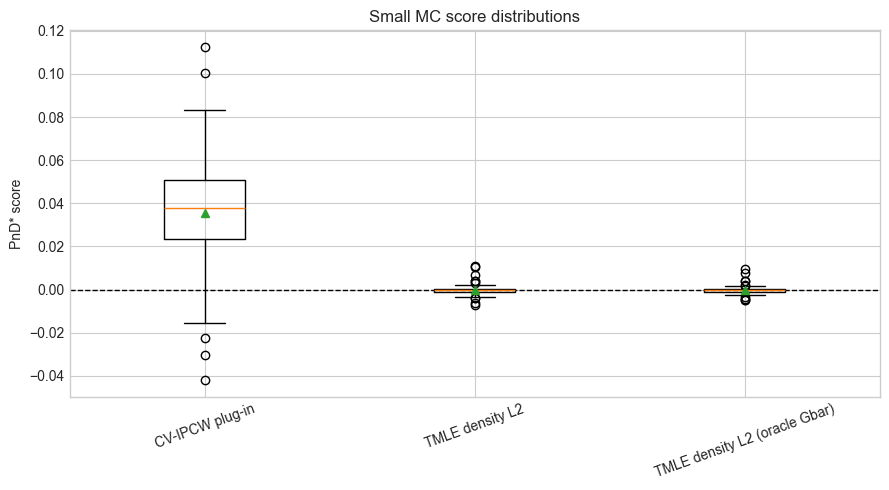

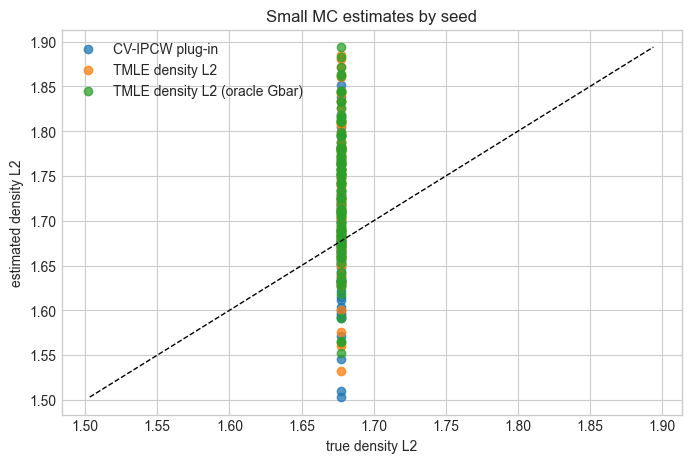

In [8]:
if "pnd_star" not in mc_results.columns or "abs_pnd_star" not in mc_results.columns:
    mc_results = mc_results.copy()
    is_tmle = mc_results["method"].str.startswith("TMLE")
    mc_results["pnd_star"] = np.where(is_tmle, mc_results["final_pnd_star"], mc_results["initial_pnd_star"])
    mc_results["abs_pnd_star"] = np.abs(mc_results["pnd_star"].to_numpy(dtype=float))

if "tmle_default_se" not in mc_results.columns and "tmle_se_all_eic" in mc_results.columns:
    mc_results = mc_results.copy()
    mc_results["tmle_default_se"] = mc_results["tmle_se_all_eic"]
if "tmle_clip_active_filtered_se" not in mc_results.columns and "tmle_filtered_se" in mc_results.columns:
    mc_results = mc_results.copy()
    mc_results["tmle_clip_active_filtered_se"] = mc_results["tmle_filtered_se"]

mc_summary = summarize_mc(mc_results)
tmle_results = mc_results[mc_results["method"].str.startswith("TMLE")].copy()
flagged = tmle_results.loc[
    (tmle_results["clip_active_eic_excluded_count"] > 0)
    | (tmle_results["tmle_default_se"] > tmle_results["tmle_default_se"].median() * 10),
    [
        "seed",
        "method",
        "censoring_model",
        "estimate",
        "targeting_gbar_floor",
        "tmle_default_se",
        "tmle_clip_active_filtered_se",
        "initial_pnd_star",
        "final_pnd_star",
        "pnd_star",
        "clip_active_eic_included_count",
        "clip_active_eic_excluded_count",
        "clip_active_eic_excluded_rate",
        "tmle_ci_lower",
        "tmle_ci_upper",
        "min_gbar",
        "max_ipcw_weight",
    ],
].sort_values("clip_active_eic_excluded_rate", ascending=False)
score_summary = mc_results.groupby("method", sort=False).agg(
    mean_pnd_star=("pnd_star", "mean"),
    median_pnd_star=("pnd_star", "median"),
    mean_abs_pnd_star=("abs_pnd_star", "mean"),
    median_abs_pnd_star=("abs_pnd_star", "median"),
    q90_abs_pnd_star=("abs_pnd_star", lambda x: float(np.quantile(np.asarray(x, dtype=float), 0.9))),
).reset_index()
run_diagnostics = pd.DataFrame([
    {
        "n_seeds": int(mc_results["seed"].nunique()),
        "n_rows": int(len(mc_results)),
        "n_tmle_rows": int(len(tmle_results)),
        "n_converged_tmle": int(tmle_results["converged"].sum()),
        "n_not_converged_tmle": int((~tmle_results["converged"]).sum()),
        "n_clip_active_flagged": int((tmle_results["clip_active_eic_excluded_count"] > 0).sum()),
        "median_runtime_seconds_per_seed": float(mc_results.groupby("seed")["runtime_seconds"].first().median()),
        "mean_censoring_rate": float(mc_results.groupby("seed")["censoring_rate"].first().mean()),
        "median_max_ipcw_weight": float(mc_results.groupby("seed")["max_ipcw_weight"].first().median()),
    }
])

display(mc_summary)
display(score_summary)
display(run_diagnostics)
display(flagged)

score_methods = list(mc_results.groupby("method", sort=False).groups)
score_values = [
    mc_results.loc[mc_results["method"] == method, "pnd_star"].dropna().to_numpy(dtype=float)
    for method in score_methods
]
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(score_values, tick_labels=score_methods, showmeans=True)
ax.axhline(0.0, color="black", linestyle="--", linewidth=1)
ax.set_ylabel("PnD* score")
ax.set_title("Small MC score distributions")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for method, group in mc_results.groupby("method", sort=False):
    ax.scatter(group["truth"], group["estimate"], alpha=0.75, label=method)
lo = min(mc_results["truth"].min(), mc_results["estimate"].min())
hi = max(mc_results["truth"].max(), mc_results["estimate"].max())
ax.plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=1)
ax.set_xlabel("true density L2")
ax.set_ylabel("estimated density L2")
ax.set_title("Small MC estimates by seed")
ax.legend()
plt.show()


In [9]:
# Removed. The main MC cell above now performs the three-way comparison.

# Removed. The main MC cell above now performs the three-way comparison.

## Notes

The target `integral p^2` can be larger than one, so the Wald CI is not clipped to `[0, 1]`. For the density-L2 TMLE, inference now uses all regularized EICs under the adaptive `targeting_gbar_floor`; the `clip_active_eic_*` counts and `standard_error_clip_active_filtered` are retained only as tail diagnostics.
